# Q8: Surface Defect Detection using YOLOv8

## Objective
Build an object detection model to automatically detect defects on steel/metal surfaces using the NEU Surface Defect Dataset.

Dataset:
https://universe.roboflow.com/pavithraa-sekar/neu-surface-defect-dataset

# Part A: Data Preparation (25 Marks)

## Step 1: Install Required Libraries

In [8]:
!pip install ultralytics
!pip install roboflow

## Step 2: Download Dataset from Roboflow

In [9]:
from roboflow import Roboflow

rf = Roboflow(api_key="xFPQpxd6Ubz3SjZaACUy")

project = rf.workspace("pavithraa-sekar").project(
    "neu-surface-defect-dataset"
)

dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## Verify Dataset Structure

In [10]:
import os

dataset_path = dataset.location
print(os.listdir(dataset_path))

['README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'valid', 'train']


Expected output:

```
train/
valid/
test/
data.yaml
```

## Verify Images and Labels

In [11]:
train_images = os.listdir(f"{dataset_path}/train/images")
train_labels = os.listdir(f"{dataset_path}/train/labels")

print("Images :", len(train_images))
print("Labels :", len(train_labels))

Images : 1439
Labels : 1439


## Verify data.yaml

In [12]:
with open(f"{dataset_path}/data.yaml") as f:
    print(f.read())

names:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches
nc: 6
roboflow:
  license: CC BY 4.0
  project: neu-surface-defect-dataset
  url: https://universe.roboflow.com/pavithraa-sekar/neu-surface-defect-dataset/dataset/1
  version: 1
  workspace: pavithraa-sekar
test: ../test/images
train: ../train/images
val: ../valid/images



## Display Sample Images with Bounding Boxes

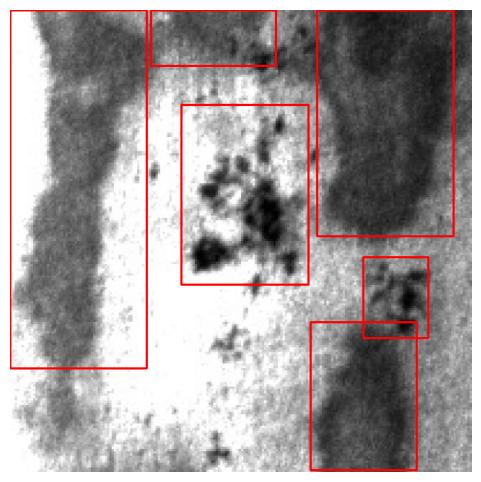

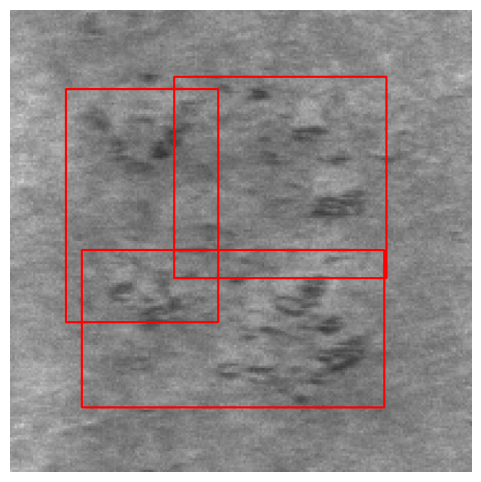

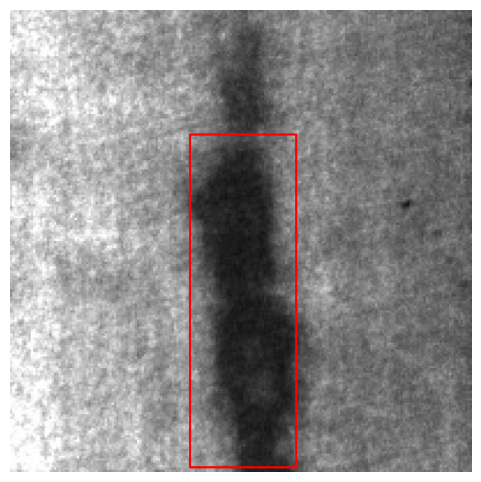

In [13]:
import cv2
import matplotlib.pyplot as plt
import random
import os

image_dir = f"{dataset_path}/train/images"
label_dir = f"{dataset_path}/train/labels"

samples = random.sample(os.listdir(image_dir), 3)

for file in samples:
    img_path = os.path.join(image_dir, file)
    label_path = os.path.join(label_dir, file.replace(".jpg",".txt"))

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h,w,_ = image.shape

    with open(label_path) as f:
        boxes = f.readlines()

    for box in boxes:
        cls,x,y,bw,bh = map(float, box.split())

        x1 = int((x-bw/2)*w)
        y1 = int((y-bh/2)*h)
        x2 = int((x+bw/2)*w)
        y2 = int((y+bh/2)*h)

        cv2.rectangle(image,(x1,y1),(x2,y2),(255,0,0),2)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Part B: Model Training and Evaluation (10 Marks)

In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [15]:
results = model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NEU-Surface-Defect-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [16]:
results = model.val()
print(results)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1157.7±689.3 MB/s, size: 39.7 KB)
val: Scanning /content/NEU-Surface-Defect-Dataset-1/valid/labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 107.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 4.7it/s 4.8s
                   all        360        854      0.672       0.66      0.716      0.373
               crazing         60        162      0.579      0.221       0.38      0.147
             inclusion         71        159      0.773      0.761      0.828      0.443
               patches         73        193      0.834      0.907      0.941      0.585
        pitted_surface         60         87      0.769      0.713      0.808      0.423
       rolled-in_scale     

# Important Metrics

- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95


## Precision

Precision = TP / (TP + FP)

Measures how many predicted defects are actually defects.

## Recall

Recall = TP / (TP + FN)

Measures how many actual defects are detected.

## mAP@0.5

Mean Average Precision at IoU threshold of 0.5.

## mAP@0.5:0.95

Average mAP computed from IoU thresholds 0.5 to 0.95.

## Display Training Curves

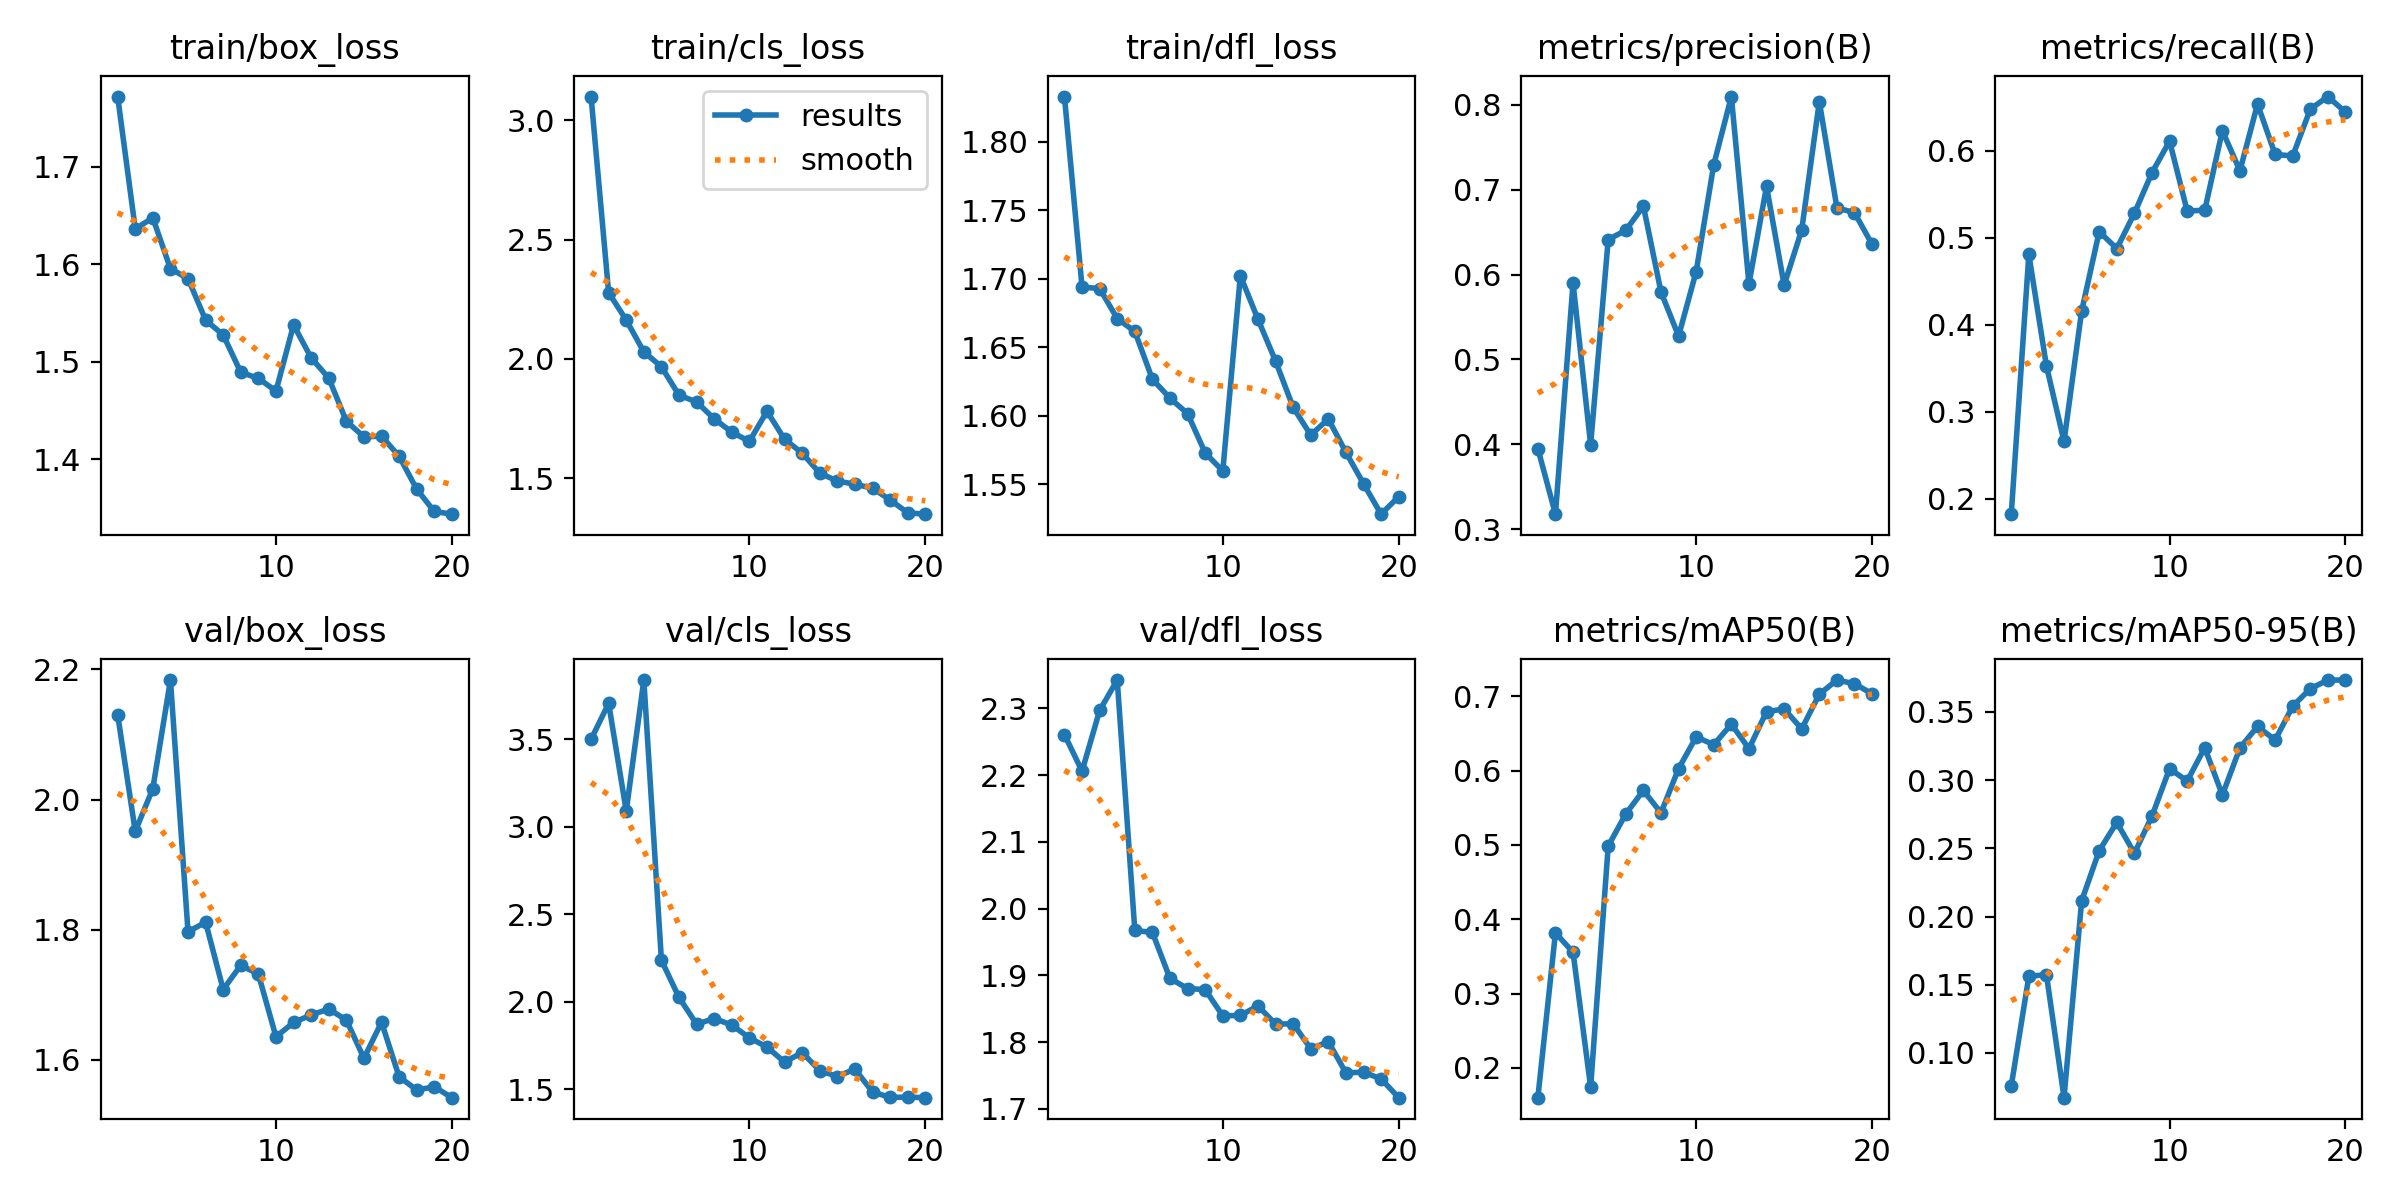

In [17]:
from IPython.display import Image

Image(filename="runs/detect/train/results.png")

# Part C: Model Inference

In [18]:
best_model = YOLO(
    "runs/detect/train/weights/best.pt"
)

In [20]:
results = best_model.predict(
    source=f"{dataset_path}/valid/images", # Changed from test/images to valid/images
    save=True,
    conf=0.25
)


image 1/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_241_jpg.rf.17c031adb49a4138cd3ce5e1aa903726.jpg: 640x640 1 crazing, 9.1ms
image 2/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_242_jpg.rf.854c2b1cbbd1d8f4b0ca2e8f172b2ec7.jpg: 640x640 1 crazing, 7.2ms
image 3/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_243_jpg.rf.6c309bb741a3b0b699b6b1194b29a528.jpg: 640x640 (no detections), 7.2ms
image 4/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_244_jpg.rf.f2226f41372b73f0f9da315f362f5ace.jpg: 640x640 2 crazings, 7.2ms
image 5/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_245_jpg.rf.4142d01b14c8c31e4d4b171fd31ff07c.jpg: 640x640 3 crazings, 7.2ms
image 6/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_246_jpg.rf.29eaf7e6c74ec6c95fdee4b573dab72e.jpg: 640x640 1 crazing, 7.2ms
image 7/360 /content/NEU-Surface-Defect-Dataset-1/valid/images/crazing_247_jpg.rf.f21d74c53f6b6eb2e8091d322732062c.jpg: 6

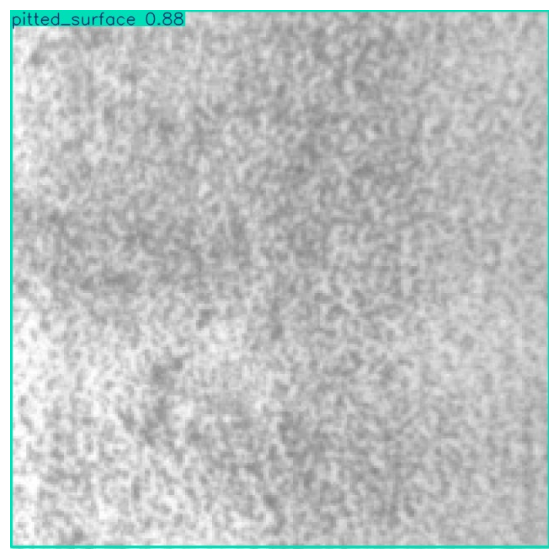

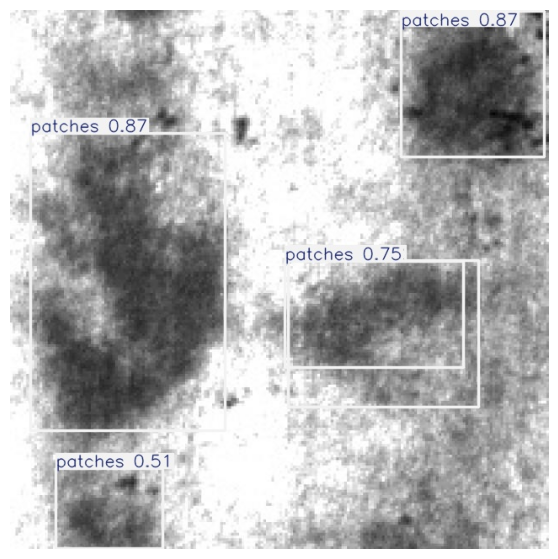

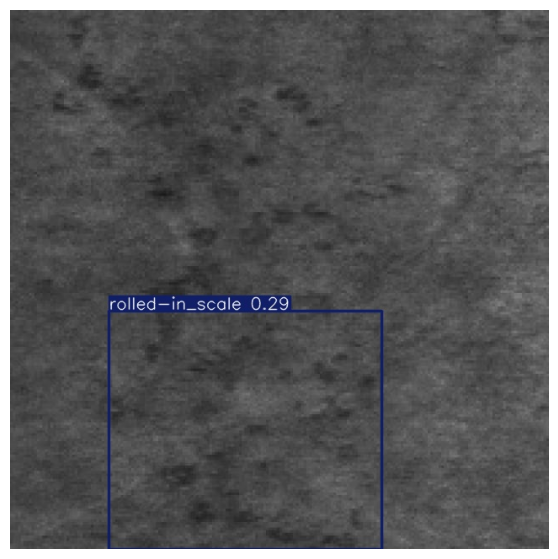

In [21]:
from glob import glob
import matplotlib.pyplot as plt

pred_images = glob("runs/detect/predict/*.jpg")

for img in pred_images[:3]:
    plt.figure(figsize=(7,7))
    plt.imshow(plt.imread(img))
    plt.axis("off")
    plt.show()

In [22]:
import shutil

for i,img in enumerate(pred_images[:3]):
    shutil.copy(img, f"Q8_output_{i+1}.jpg")

In [24]:
best_model.predict(
    source="patches_205.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/patches_205.jpg: 640x640 4 patchess, 9.8ms
Speed: 2.7ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[ 41,  41,  41],
         [ 43,  43,  43],
         [ 36,  36,  36],
         ...,
         [135, 135, 135],
         [137, 137, 137],
         [133, 133, 133]],
 
        [[ 45,  45,  45],
         [ 37,  37,  37],
         [ 46,  46,  46],
         ...,
         [134, 134, 134],
         [155, 155, 155],
         [132, 132, 132]],
 
        [[ 37,  37,  37],
         [ 38,  38,  38],
         [ 36,  36,  36],
         ...,
         [156, 156, 156],
         [141, 141, 141],
         [135, 135, 135]],
 
        ...,
 
        [[ 15,  15,  15],
         [ 16,  16,  16],
         [ 15,  15,  15],
         ...,
         [133, 133, 133],
         [154, 154, 154],
         [133, 133, 133]],
 
        [[ 15,  15, 

# False Positives

- Surface texture resembles defects.
- Poor lighting.
- Noise in image.
- Incorrect annotations.


# False Negatives

- Small defects.
- Blurred images.
- Insufficient training data.
- Class imbalance.
- Occlusion.


# Files to Submit

- Q8_YOLO_Surface_Defect_Detection.ipynb
- Q8_best_model.pt
- Q8_output_1.jpg
- Q8_output_2.jpg
- Q8_output_3.jpg
- Q8_training_results.png
- Q8_metrics_screenshot.pdf


# Workflow Diagram

Dataset → Verify YOLO Structure → Display Bounding Boxes → Train YOLOv8n (20 Epochs) → Evaluate Metrics → Inference on Test Images → Save Detection Results
